# USDC Depeg: Hourly Network Centrality Analysis

This notebook rebuilds the USDC depeg analysis from the saved hourly transfer network and the existing address labels. The goal is to track how hourly centrality changes around the March 11, 2023 depeg, with special attention to in-strength spikes in the main pools and smart contracts.

The notebook emphasizes three questions:
1. Which nodes absorb the largest inflow spikes during the depeg?
2. Do weighted and unweighted centrality move together?
3. Do USDC-USDT pools pick up more depeg-time flow than the main WETH-USDC pools?

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="white", context="notebook")
pd.options.display.float_format = "{:,.4f}".format

ROOT = Path.cwd()
DATA_FILE = ROOT / "USDC_transfers_hourly.parquet"
LABEL_FILE = ROOT / "address_labels.csv"

WINDOW_START = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
WINDOW_END = pd.Timestamp("2023-03-12 23:00:00", tz="UTC")
PRE_START = pd.Timestamp("2023-03-10 00:00:00", tz="UTC")
PRE_END = pd.Timestamp("2023-03-11 02:00:00", tz="UTC")
EVENT_START = pd.Timestamp("2023-03-11 03:11:00", tz="UTC")
EVENT_END = pd.Timestamp("2023-03-11 23:00:00", tz="UTC")
DEPEG_TS = EVENT_START

CATEGORY_COLORS = {
        "dex_pool": "#1f77b4",
        "aggregator_router": "#ff7700",
        "router_helper": "#ffbb78",
        "settlement_contract": "#2ca02c",
        "dex_vault": "#9467bd",
        "lending_token": "#f7cc32",
        "resolver": "#e377c2",
        "issuer": "#17becf",
        "CEX": "#1CFFB3FF",
        "mev_bot": "crimson",
        "unknown_contract": "#7f7f7f",
        "unknown": "#bdbdbd",
    }

MANUAL_LABELS = {
    "0xba12222222228d8ba445958a75a0704d566bf2c8": {
        "entity": "Balancer_Vault",
        "category": "dex_vault",
        "short_label": "Balancer Vault",
        "family": "Infrastructure",
    },
    "0xbcca60bb61934080951369a648fb03df4f96263c": {
        "entity": "Aave_aUSDC_Token_V2",
        "category": "lending_token",
        "short_label": "Aave aUSDC",
        "family": "Lending",
    },
    "0x1111111254eeb25477b68fb85ed929f73a960582": {
        "entity": "OneInch_Aggregation_Router_V5",
        "category": "aggregator_router",
        "short_label": "1inch Router",
        "family": "Routing",
    },
    "0xef1c6e67703c7bd7107eed8303fbe6ec2554bf6b": {
        "entity": "Uniswap_Universal_Router_2",
        "category": "aggregator_router",
        "short_label": "Uniswap Router",
        "family": "Routing",
    },
    "0x9008d19f58aabd9ed0d60971565aa8510560ab41": {
        "entity": "CoW_Protocol_GPv2Settlement",
        "category": "settlement_contract",
        "short_label": "CoW Settlement",
        "family": "Routing",
    },
}

# Plot transfer graph

In [125]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_graph_at_time(
    df_net,
    t,
    node_metric="in_strength",
    min_edge_weight=0,
    min_node_volume=0
):
    t = pd.Timestamp(t, tz="UTC")
    df_t = df_net[df_net["ts_hour"] == t].copy()

    if min_edge_weight > 0:
        df_t = df_t[df_t["amount_usdc"] >= min_edge_weight].copy()

    if df_t.empty:
        print(f"No data for {t}")
        return

    # node total incident volume = in + out
    if min_node_volume > 0:
        out_vol = df_t.groupby("source", as_index=False)["amount_usdc"].sum()
        out_vol = out_vol.rename(columns={"source": "node", "amount_usdc": "out_volume"})

        in_vol = df_t.groupby("target", as_index=False)["amount_usdc"].sum()
        in_vol = in_vol.rename(columns={"target": "node", "amount_usdc": "in_volume"})

        node_vol = out_vol.merge(in_vol, on="node", how="outer").fillna(0)
        node_vol["total_volume"] = node_vol["in_volume"] + node_vol["out_volume"]

        keep_nodes = set(
            node_vol.loc[node_vol["total_volume"] >= min_node_volume, "node"]
        )

        df_t = df_t[
            df_t["source"].isin(keep_nodes) & df_t["target"].isin(keep_nodes)
        ].copy()

    if df_t.empty:
        print(f"No data left for {t} after filtering.")
        return

    G = nx.DiGraph()
    for row in df_t.itertuples(index=False):
        G.add_edge(row.source, row.target, weight=float(row.amount_usdc))

    # node size metric
    if node_metric == "in_degree":
        metric = dict(G.in_degree())
        sizes = [200 + 300 * np.sqrt(metric.get(n, 0)) for n in G.nodes()]
    elif node_metric == "pagerank":
        metric = nx.pagerank(G, weight="weight")
        max_metric = max(metric.values()) if metric else 1
        sizes = [20+ 500 * (metric.get(n, 0) / max_metric) for n in G.nodes()]
    else:  # in_strength
        metric = dict(G.in_degree(weight="weight"))
        max_metric = max(metric.values()) if metric else 1
        sizes = [20+ 400 * (metric.get(n, 0) / max_metric) for n in G.nodes()]
    
    node_categories = {n: category_map.get(n, "unknown") for n in G.nodes()}
    node_colors = [
        CATEGORY_COLORS.get(category_map.get(n, "unknown"), CATEGORY_COLORS["unknown"])
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=42, weight="weight",k=120)
    max_weight = max(d["weight"] for _, _, d in G.edges(data=True)) if G.edges else 1
    edge_widths = [0.2 + np.log1p(d["weight"]) / np.log1p(max_weight) for _, _, d in G.edges(data=True)]

    plt.figure(figsize=(12, 12))
    nx.draw_networkx_edges(G, pos, arrows=True, alpha=0.15, width=edge_widths, node_size=sizes, edge_color = 'grey')
    nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.9, node_color=node_colors,
        edgecolors="black", linewidths=0.5)

    # label top 100 nodes by chosen metric
    # top_nodes = sorted(metric, key=metric.get, reverse=True)[:100]
    # labels = {n: n for n in top_nodes}
    # nx.draw_networkx_labels(G, pos, labels=labels, font_size=10,font_color = 'k')

    # label top 100 nodes by chosen metric
    top_nodes = sorted(metric, key=metric.get, reverse=True)[:20]
    labels = {n: ("" if isinstance(n, str) and n.startswith("0x") else n) for n in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color='k')
    
    present_categories = sorted(set(node_categories.values()))
    legend_handles = [
        Patch(
            facecolor=CATEGORY_COLORS.get(cat, CATEGORY_COLORS["unknown"]),
            edgecolor="black",
            label=cat
        )
        for cat in present_categories
    ]

    plt.legend(
        handles=legend_handles,
        loc="upper left",
        ncols = 5,
        frameon = False,
        bbox_to_anchor=(.05, 0.02),
        borderaxespad=0
    )
    plt.title(
        f"USDC network at {t}\n"
        f"node size={node_metric}, min_edge_weight={min_edge_weight}, min_node_volume={min_node_volume}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f'USDC_transfers_network_{t}.png', dpi = 300,transparent = True, bbox_inches = 'tight')

In [126]:
def load_inputs(data_file=DATA_FILE, label_file=LABEL_FILE):
    df = pd.read_parquet(data_file).copy()
    labels = pd.read_csv(label_file).copy()

    labels["address"] = labels["address"].str.lower()
    labels["entity"] = labels["entity"].fillna(labels["address"])
    labels["category"] = labels["category"].fillna("unknown")
    labels["short_label"] = labels["entity"]
    labels["family"] = labels["category"]

    for address, meta in MANUAL_LABELS.items():
        mask = labels["address"] == address
        if mask.any():
            labels.loc[mask, "entity"] = meta["entity"]
            labels.loc[mask, "category"] = meta["category"]
            labels.loc[mask, "short_label"] = meta["short_label"]
            labels.loc[mask, "family"] = meta["family"]
        else:
            labels = pd.concat([
                labels,
                pd.DataFrame([{
                    "address": address,
                    "entity": meta["entity"],
                    "category": meta["category"],
                    "short_label": meta["short_label"],
                    "family": meta["family"],
                }]),
            ], ignore_index=True)

    df["ts_hour"] = pd.to_datetime(df["ts_hour"], utc=True)
    df["from_address"] = df["from_address"].str.lower()
    df["to_address"] = df["to_address"].str.lower()
    df["amount_usdc"] = pd.to_numeric(df["amount_usdc"], errors="coerce")
    df = df.dropna(subset=["amount_usdc"]).copy()

    entity_map = dict(zip(labels["address"], labels["entity"]))
    short_label_map = dict(zip(labels["entity"], labels["short_label"]))
    category_map = dict(zip(labels["entity"], labels["category"]))
    family_map = dict(zip(labels["entity"], labels["family"]))

    df["source"] = df["from_address"].map(entity_map).fillna(df["from_address"])
    df["target"] = df["to_address"].map(entity_map).fillna(df["to_address"])

    return df, labels, category_map, short_label_map, family_map


df_raw, labels, category_map, short_label_map, family_map = load_inputs()
df_window = df_raw[df_raw["ts_hour"].between(WINDOW_START, WINDOW_END)].copy()
df_net = (
    df_window.groupby(["ts_hour", "source", "target"], as_index=False)["amount_usdc"]
    .sum()
)

overview = pd.DataFrame({
    "metric": ["rows in hourly parquet", "rows in analysis window", "hourly edges", "labelled addresses"],
    "value": [len(df_raw), len(df_window), len(df_net), labels["address"].nunique()],
})
display(overview)
display(labels[labels["address"].isin(MANUAL_LABELS)][["address", "entity", "short_label", "category", "family"]].sort_values("family"))

,metric,value
0,rows in hourly parquet,395193
1,rows in analysis window,327022
2,hourly edges,327022
3,labelled addresses,100


,address,entity,short_label,category,family
32,0xba12222222228d8ba445958a75a0704d566bf2c8,Balancer_Vault,Balancer Vault,dex_vault,Infrastructure
13,0xbcca60bb61934080951369a648fb03df4f96263c,Aave_aUSDC_Token_V2,Aave aUSDC,lending_token,Lending
36,0x1111111254eeb25477b68fb85ed929f73a960582,OneInch_Aggregation_Router_V5,1inch Router,aggregator_router,Routing
40,0xef1c6e67703c7bd7107eed8303fbe6ec2554bf6b,Uniswap_Universal_Router_2,Uniswap Router,aggregator_router,Routing
67,0x9008d19f58aabd9ed0d60971565aa8510560ab41,CoW_Protocol_GPv2Settlement,CoW Settlement,settlement_contract,Routing


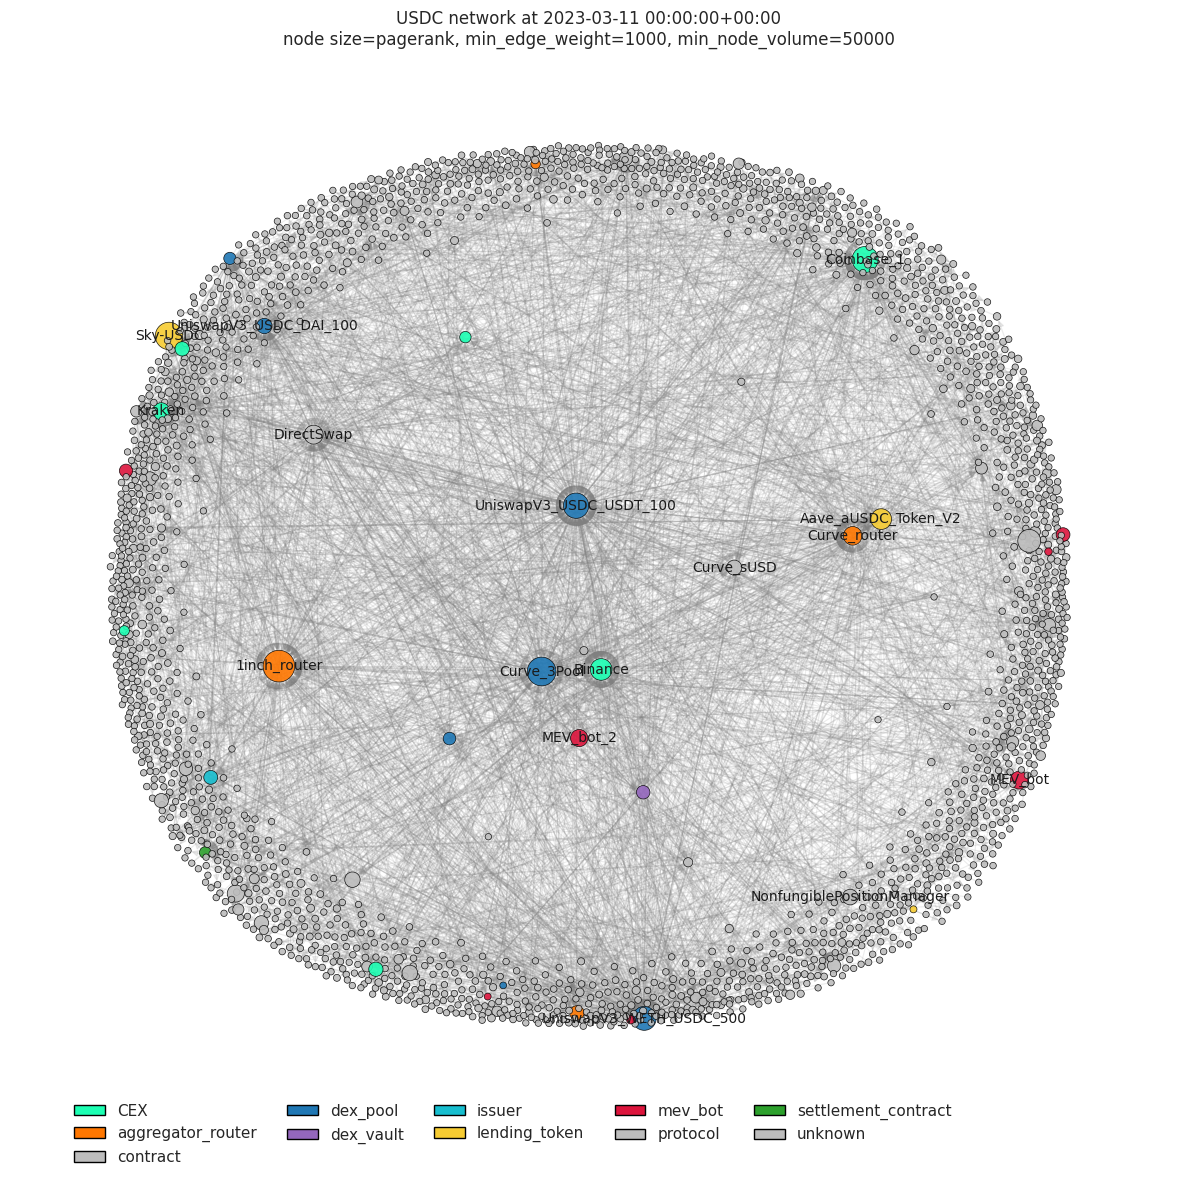

In [114]:
plot_graph_at_time(
    df_net,
    "2023-03-11 00:00:00+00:00",
    node_metric="pagerank",
    min_edge_weight=1000,
    min_node_volume=50000
)

In [127]:
def build_graph(df_hour):
    graph = nx.DiGraph()
    for row in df_hour.itertuples(index=False):
        weight = float(row.amount_usdc)
        if weight <= 0:
            continue
        graph.add_edge(row.source, row.target, weight=weight)
    return graph


def compute_hourly_metrics(df_edges):
    node_rows = []
    graph_rows = []

    for ts_hour, sub in df_edges.groupby("ts_hour", sort=True):
        graph = build_graph(sub)
        if graph.number_of_nodes() == 0:
            continue

        in_degree = dict(graph.in_degree())
        out_degree = dict(graph.out_degree())
        in_strength = dict(graph.in_degree(weight="weight"))
        out_strength = dict(graph.out_degree(weight="weight"))
        pagerank = nx.pagerank(graph, alpha=0.85, weight="weight")

        graph_rows.append({
            "ts_hour": ts_hour,
            "total_volume": sub["amount_usdc"].sum(),
            "active_nodes": graph.number_of_nodes(),
            "active_edges": graph.number_of_edges(),
            "density": nx.density(graph) if graph.number_of_nodes() > 1 else 0.0,
        })

        for node in graph.nodes():
            category = category_map.get(node, "unknown")
            node_rows.append({
                "ts_hour": ts_hour,
                "node": node,
                "short_label": short_label_map.get(node, node),
                "family": family_map.get(node, category),
                "category": category,
                "in_degree": in_degree.get(node, 0),
                "out_degree": out_degree.get(node, 0),
                "in_strength": in_strength.get(node, 0.0),
                "out_strength": out_strength.get(node, 0.0),
                "pagerank": pagerank.get(node, 0.0),
            })

    return pd.DataFrame(node_rows), pd.DataFrame(graph_rows)


node_metrics, graph_metrics = compute_hourly_metrics(df_net)
display(graph_metrics.head())
display(node_metrics.head())

,ts_hour,total_volume,active_nodes,active_edges,density
0,2023-03-10 00:00:00+00:00,"1,045,504,463.3250",2666,3074,0.0004
1,2023-03-10 01:00:00+00:00,"795,932,814.3327",2767,3257,0.0004
2,2023-03-10 02:00:00+00:00,"819,000,292.7908",2393,2506,0.0004
3,2023-03-10 03:00:00+00:00,"2,648,365,189.0221",2134,2285,0.0005
4,2023-03-10 04:00:00+00:00,"1,111,570,341.8022",2122,2417,0.0005


,ts_hour,node,short_label,family,category,in_degree,out_degree,in_strength,out_strength,pagerank
0,2023-03-10 00:00:00+00:00,0x0000000000007f150bd6f54c40a34d7c3d5e9f56,0x0000000000007f150bd6f54c40a34d7c3d5e9f56,unknown,unknown,2,1,"26,264.5621","26,264.5621",0.0003
1,2023-03-10 00:00:00+00:00,UniswapV3_WETH_USDC_100,UniswapV3_WETH_USDC_100,dex_pool,dex_pool,53,50,"7,794,253.6783","7,987,172.0512",0.0135
2,2023-03-10 00:00:00+00:00,0x000000000005af2ddc1a93a03e9b7014064d3b8d,0x000000000005af2ddc1a93a03e9b7014064d3b8d,unknown,unknown,2,2,"27,410.8454","27,395.6584",0.0002
3,2023-03-10 00:00:00+00:00,0xc72abb13b6bdfa64770cb5b1f57bebd36a91a29e,0xc72abb13b6bdfa64770cb5b1f57bebd36a91a29e,unknown,unknown,9,4,"16,017.3087","40,781.3415",0.0006
4,2023-03-10 00:00:00+00:00,0x00000000000747d525e898424e8774f7eb317d00,0x00000000000747d525e898424e8774f7eb317d00,unknown,unknown,1,1,"2,718.6189","2,657.9064",0.0002


## Network Activity Around the Depeg

Before looking at individual nodes, it helps to anchor the network-level backdrop: transfer volume, active nodes, and active edges all change abruptly around the depeg window.

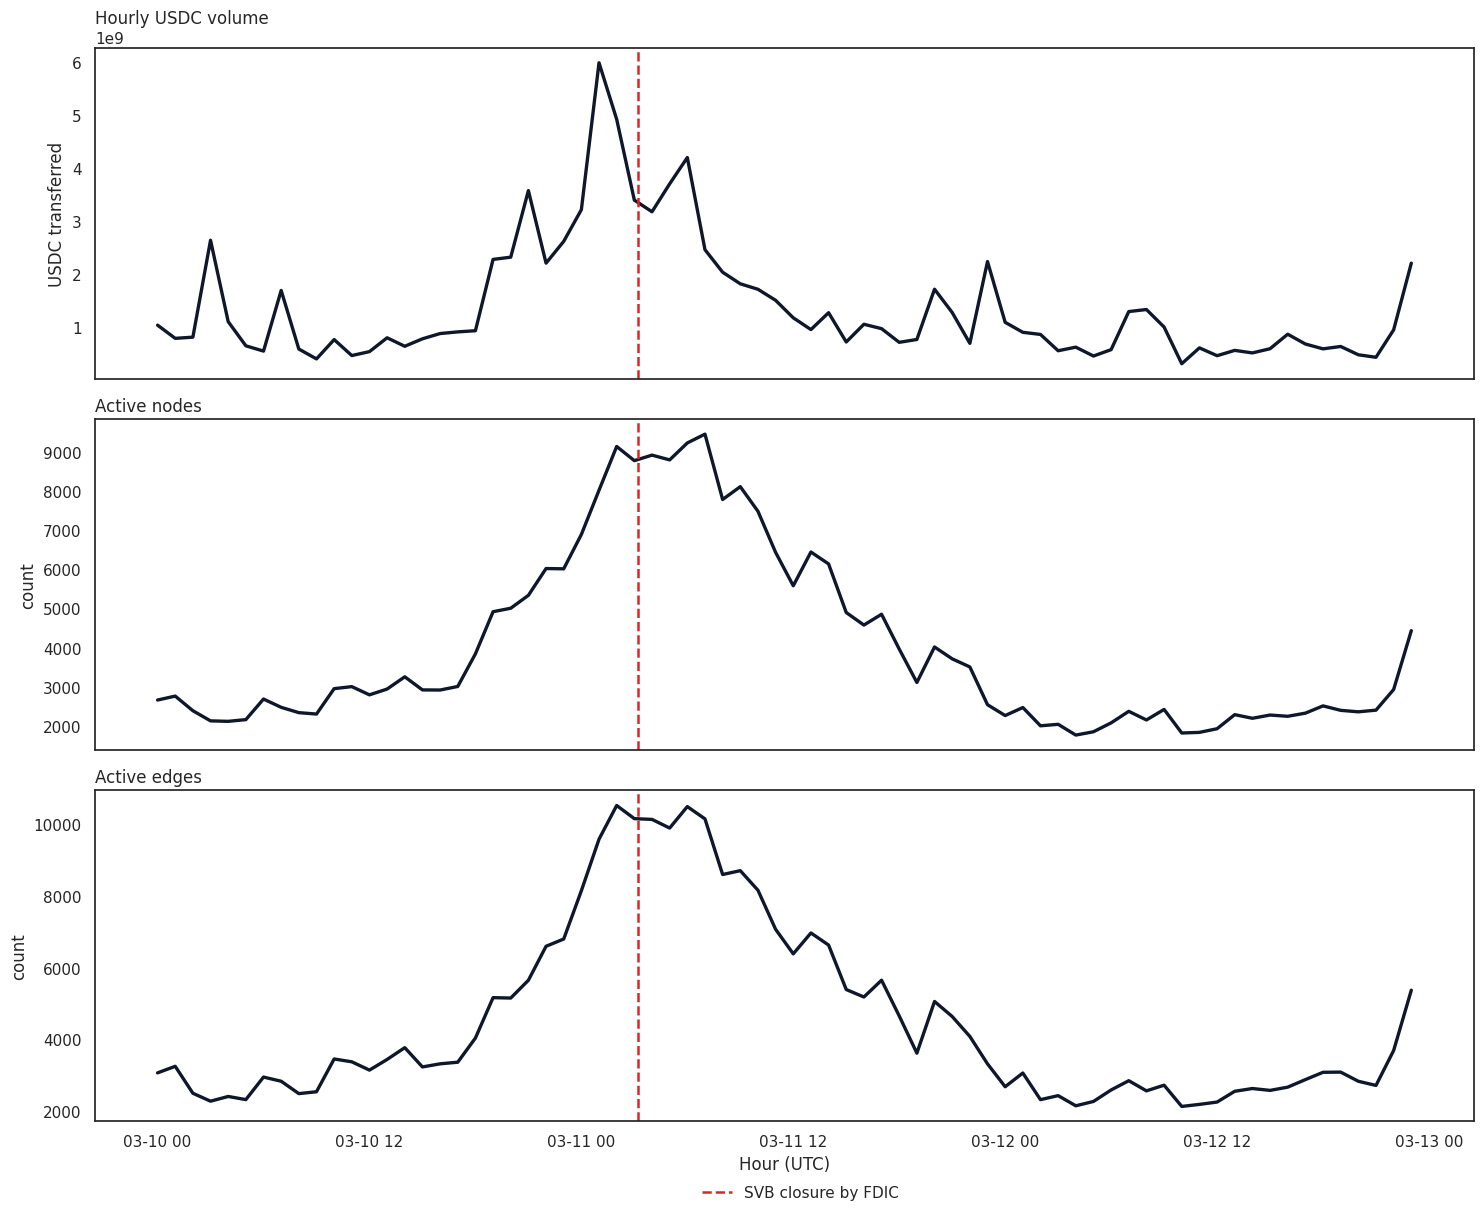

In [128]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
series_to_plot = [
    ("total_volume", "Hourly USDC volume", "USDC transferred"),
    ("active_nodes", "Active nodes", "count"),
    ("active_edges", "Active edges", "count"),
]

for ax, (metric, title, ylabel) in zip(axes, series_to_plot):
    ax.plot(graph_metrics["ts_hour"], graph_metrics[metric], color="#0f172a", linewidth=2.4)
    ax.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8, label = "SVB closure by FDIC")
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)

axes[-1].set_xlabel("Hour (UTC)")
# fig.suptitle("USDC transfer network activity around the depeg", y=1.02, fontsize=20)
plt.tight_layout()
plt.legend(bbox_to_anchor=(.43, -0.15), loc="upper left", frameon=False)
plt.savefig('USDC_transfer_network_metrics.png', dpi=300, transparent=True, bbox_inches='tight')

In [129]:
def summarize_window_changes(node_df, pre_start=PRE_START, pre_end=PRE_END, event_start=EVENT_START, event_end=EVENT_END):
    metrics = ["in_degree", "out_degree", "in_strength", "out_strength", "pagerank"]

    pre = (
        node_df[node_df["ts_hour"].between(pre_start, pre_end)]
        .groupby(["node", "short_label", "category", "family"], as_index=False)[metrics]
        .mean()
        .rename(columns={metric: f"pre_{metric}" for metric in metrics})
    )

    event = (
        node_df[node_df["ts_hour"].between(event_start, event_end)]
        .groupby(["node", "short_label", "category", "family"], as_index=False)[metrics]
        .mean()
        .rename(columns={metric: f"event_{metric}" for metric in metrics})
    )

    merged = pre.merge(event, on=["node", "short_label", "category", "family"], how="outer").fillna(0)

    for metric in metrics:
        merged[f"delta_abs_{metric}"] = merged[f"event_{metric}"] - merged[f"pre_{metric}"]
        baseline = merged[f"pre_{metric}"].replace(0, np.nan)
        merged[f"delta_ratio_{metric}"] = merged[f"event_{metric}"] / baseline
        merged[f"delta_log_{metric}"] = np.log1p(merged[f"event_{metric}"]) - np.log1p(merged[f"pre_{metric}"])

    merged["is_labelled"] = ~merged["node"].str.fullmatch(r"0x[a-f0-9]{40}")
    return merged.sort_values("delta_abs_in_strength", ascending=False)


window_changes = summarize_window_changes(node_metrics)
top_spikes = window_changes[window_changes["is_labelled"]].head(12)[[
    "short_label",
    "family",
    "category",
    "pre_in_strength",
    "event_in_strength",
    "delta_abs_in_strength",
    "delta_ratio_in_strength",
    "delta_log_pagerank",
]]
display(top_spikes)

,short_label,family,category,pre_in_strength,event_in_strength,delta_abs_in_strength,delta_ratio_in_strength,delta_log_pagerank
135244,Sky-USDC,lending_token,lending_token,"28,021,291.2379","159,910,838.8959","131,889,547.6580",5.7068,0.0095
135212,Arrakis_DAI-USDC,dex_pool,dex_pool,"42,953,099.5294","165,276,056.4293","122,322,956.8999",3.8478,0.0103
135248,UniswapV3_USDC_USDT_500,dex_pool,dex_pool,"9,847,786.2686","71,949,619.0647","62,101,832.7961",7.3062,0.0245
135210,Aave aUSDC,Lending,lending_token,"13,731,380.2061","74,033,185.6181","60,301,805.4121",5.3915,0.0167
135226,Curve_3Pool,dex_pool,dex_pool,"33,380,213.4841","84,102,706.1167","50,722,492.6326",2.5195,0.0188
135209,1inch_router,aggregator_router,aggregator_router,"42,758,003.5763","86,941,817.0891","44,183,813.5129",2.0333,0.0119
135246,UniswapV3_USDC_DAI_500,dex_pool,dex_pool,"5,507,851.7513","46,947,421.4371","41,439,569.6858",8.5237,0.0055
135234,MEV_bot,mev_bot,mev_bot,"10,766,961.4592","42,748,435.3036","31,981,473.8445",3.9703,0.0104
135232,G-UNI_DAI_USDC,dex_pool,dex_pool,"84,107,193.4799","102,498,125.7048","18,390,932.2249",1.2187,0.0001
135245,UniswapV3_USDC_DAI_100,dex_pool,dex_pool,"15,903,960.8934","31,400,268.3975","15,496,307.5041",1.9744,0.0002


## Who Receives the Depeg Flows?

The next plots track hourly in-strength and PageRank for the main venues. In-strength highlights where raw USDC inflows concentrate; PageRank shows whether those venues also become more central in the directed flow network.

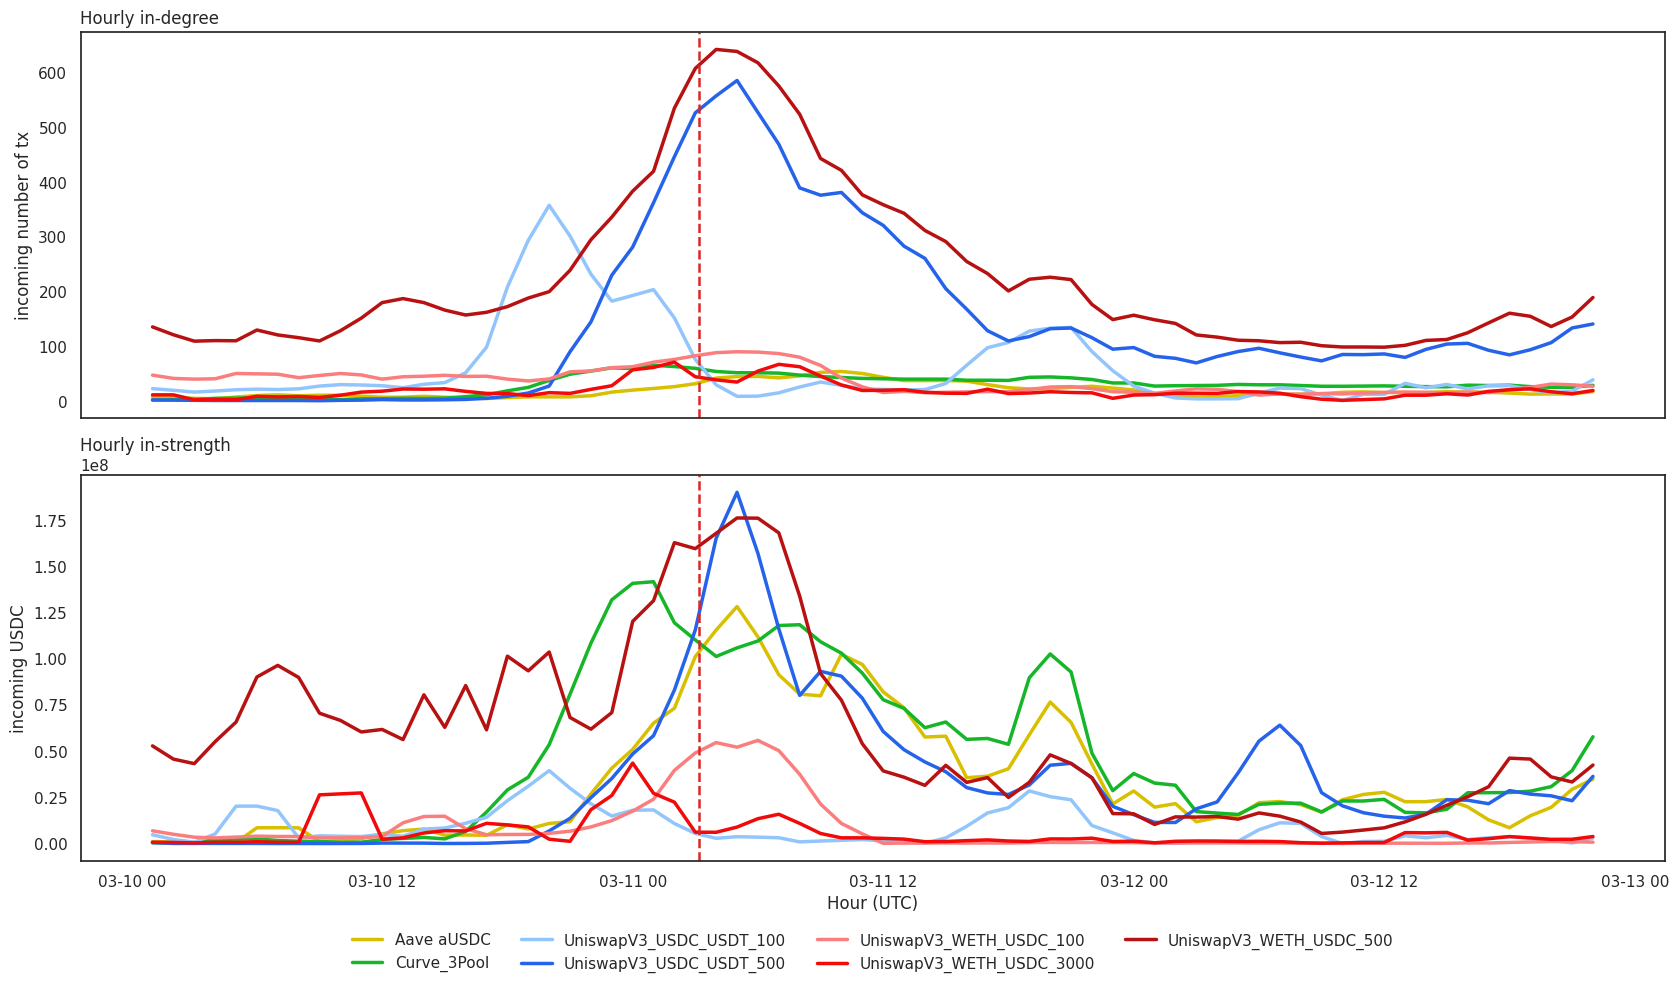

In [142]:
focus_nodes = [
    "Curve_3Pool",
    "UniswapV3_USDC_USDT_100",
    "UniswapV3_USDC_USDT_500",
    "UniswapV3_WETH_USDC_100",
    "UniswapV3_WETH_USDC_500",
    "UniswapV3_WETH_USDC_3000",
    "Aave_aUSDC_Token_V2",
]

# Semantic palette: distinct colors for Curve/Aave + gradients per Uniswap family
node_colors = {
    "Curve_3Pool": "#15b628",                     # Curve green
    "Aave_aUSDC_Token_V2": "#d8bf00",             # Aave gold
    "UniswapV3_USDC_USDT_100": "#93c5fd",         # light blue
    "UniswapV3_USDC_USDT_500": "#2563eb",         # deep blue
    "UniswapV3_WETH_USDC_100": "#fb7e7e",         # light orange
    "UniswapV3_WETH_USDC_500": "#b81111",         # orange
    "UniswapV3_WETH_USDC_3000": "#f20909",        # deep red
}

plot_df = node_metrics[node_metrics["node"].isin(focus_nodes)].copy()
plot_df["label"] = plot_df["short_label"]

if plot_df.empty:
    print("No selected focus nodes were found in node_metrics. Check focus_nodes names.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(17, 10), sharex=True)

    for node, sub in plot_df.groupby("node"):
        display_label = sub["label"].iloc[0]
        color = node_colors.get(node, "#6b7280")
        axes[0].plot(
            sub["ts_hour"],
            sub["in_degree"].rolling(3, center=True).mean(),
            linewidth=2.5,
            label=display_label,
            color=color,
        )
        axes[1].plot(
            sub["ts_hour"],
            sub["in_strength"].rolling(3, center=True).mean(),
            linewidth=2.5,
            label=display_label,
            color=color,
        )

    for ax, title, ylabel in [
        (axes[1], "Hourly in-strength", "incoming USDC"),
        (axes[0], "Hourly in-degree", "incoming number of tx"),
    ]:
        ax.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
        ax.set_title(title, loc="left")
        ax.set_ylabel(ylabel)

    axes[1].set_xlabel("Hour (UTC)")
    axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False, ncols=4)
    plt.tight_layout()
    plt.savefig("USDC_key_nodes_time_series.png", dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

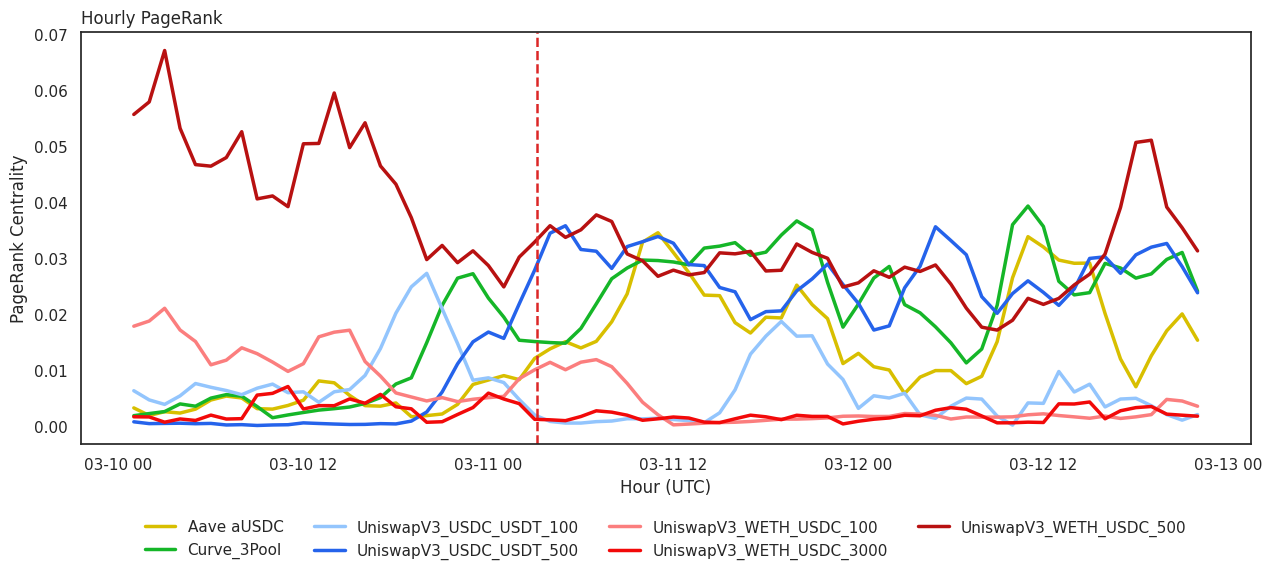

In [143]:
focus_nodes = [
    "Curve_3Pool",
    "UniswapV3_USDC_USDT_100",
    "UniswapV3_USDC_USDT_500",
    "UniswapV3_WETH_USDC_100",
    "UniswapV3_WETH_USDC_500",
    "UniswapV3_WETH_USDC_3000",
    "Aave_aUSDC_Token_V2",
]

# Semantic palette: distinct colors for Curve/Aave + gradients per Uniswap family
node_colors = {
    "Curve_3Pool": "#15b628",                     # Curve green
    "Aave_aUSDC_Token_V2": "#d8bf00",             # Aave gold
    "UniswapV3_USDC_USDT_100": "#93c5fd",         # light blue
    "UniswapV3_USDC_USDT_500": "#2563eb",         # deep blue
    "UniswapV3_WETH_USDC_100": "#fb7e7e",         # light orange
    "UniswapV3_WETH_USDC_500": "#b81111",         # orange
    "UniswapV3_WETH_USDC_3000": "#f20909",        # deep red
}

plot_df = node_metrics[node_metrics["node"].isin(focus_nodes)].copy()
plot_df["label"] = plot_df["short_label"]

if plot_df.empty:
    print("No selected focus nodes were found in node_metrics. Check focus_nodes names.")
else:
    fig, axes = plt.subplots(1, 1, figsize=(13, 6))

    for node, sub in plot_df.groupby("node"):
        display_label = sub["label"].iloc[0]
        color = node_colors.get(node, "#6b7280")
        axes.plot(
            sub["ts_hour"],
            sub["pagerank"].rolling(3, center=True).mean(),
            linewidth=2.5,
            label=display_label,
            color=color,
        )
       

    for ax, title, ylabel in [
        (axes, "Hourly PageRank", "PageRank Centrality"),
    ]:
        ax.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
        ax.set_title(title, loc="left")
        ax.set_ylabel(ylabel)

    axes.set_xlabel("Hour (UTC)")
    axes.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False, ncols=4)
    plt.tight_layout()
    plt.savefig("USDC_pagerank_time_series.png", dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

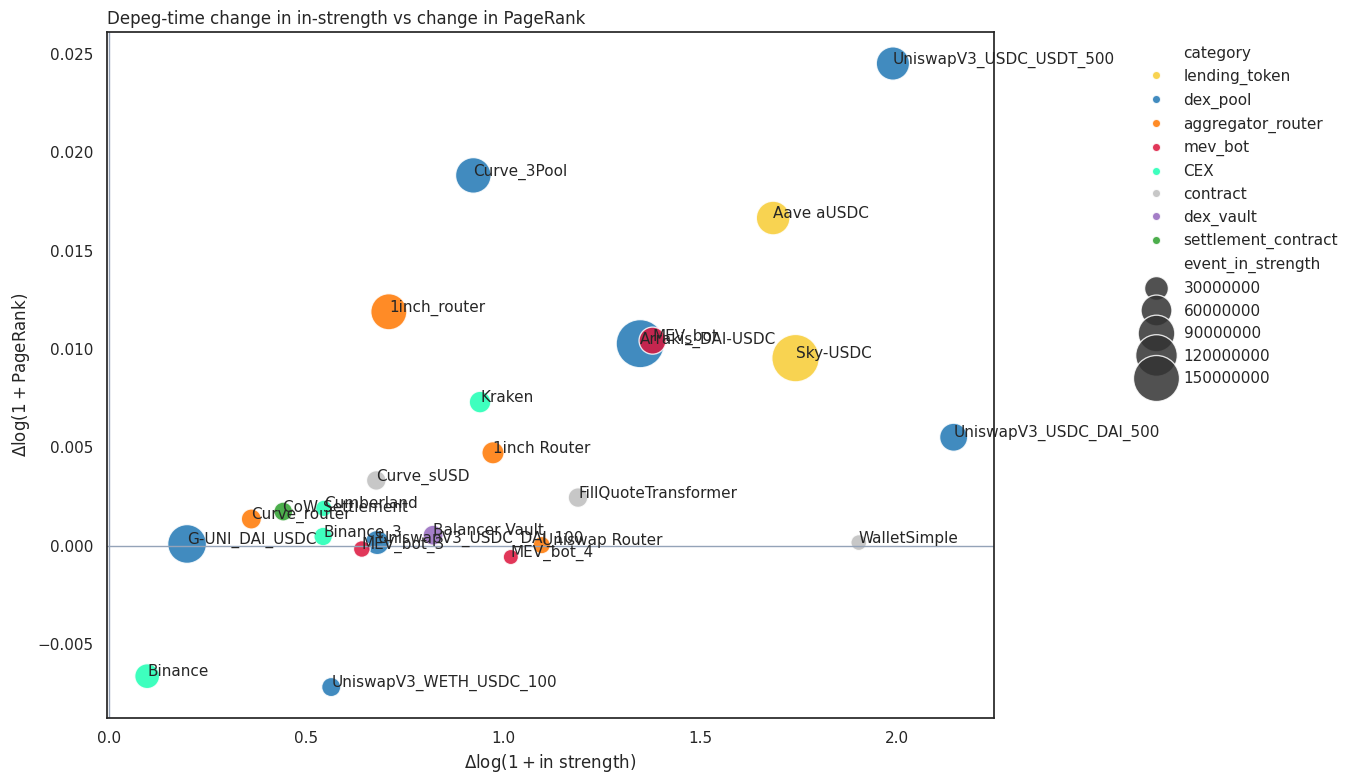

In [157]:
scatter_df = window_changes[window_changes["is_labelled"]].copy()
scatter_df = scatter_df[scatter_df["category"] != "unknown"].copy()
scatter_df = scatter_df.sort_values("delta_abs_in_strength", ascending=False).head(25)
CATEGORY_COLORS = {
        "dex_pool": "#1f77b4",
        "aggregator_router": "#ff7700",
        "router_helper": "#ffbb78",
        "settlement_contract": "#2ca02c",
        "dex_vault": "#9467bd",
        "lending_token": "#f7cc32",
        "resolver": "#e377c2",
        "issuer": "#17becf",
        "CEX": "#1CFFB3FF",
        "mev_bot": "crimson",
        "unknown_contract": "#7f7f7f",
        "unknown": "#494949",
        "contract": "#bdbdbd",
        "protocol": "#bdbdbd",
        
    }

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    data=scatter_df,
    x="delta_log_in_strength",
    y="delta_log_pagerank",
    hue="category",
    size="event_in_strength",
    sizes=(120, 1200),
    palette=CATEGORY_COLORS,
    alpha=0.85,
)

for row in scatter_df.itertuples(index=False):
    ax.text(row.delta_log_in_strength , row.delta_log_pagerank, row.short_label, fontsize=11)

plt.axhline(0, color="#94a3b8", linewidth=1)
plt.axvline(0, color="#94a3b8", linewidth=1)
plt.title("Depeg-time change in in-strength vs change in PageRank", loc="left")
plt.xlabel("$\Delta \log(1 + \mathrm{in\ strength})$")
plt.ylabel("$\Delta \log(1 + \mathrm{PageRank})$")
plt.legend(bbox_to_anchor=(1.15, 1), ncols = 1, loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig('event_centrality_change_scatter.png', dpi=300, transparent=True, bbox_inches='tight')

## Freeman Centralisation Through Time

Freeman degree centralisation is computed per hour on the directed network for both in-degree and out-degree.

For a directed graph with $n$ nodes and degree vector $d$, centralisation is

$$
C_D = \frac{\sum_i (\max(d) - d_i)}{(n-1)^2}
$$

where $(n-1)^2$ is the maximum possible numerator for a directed star.

,pre_in,event_in,pre_out,event_out,delta_in,delta_out
0,0.0683,0.0713,0.0404,0.0313,0.0029,-0.0092


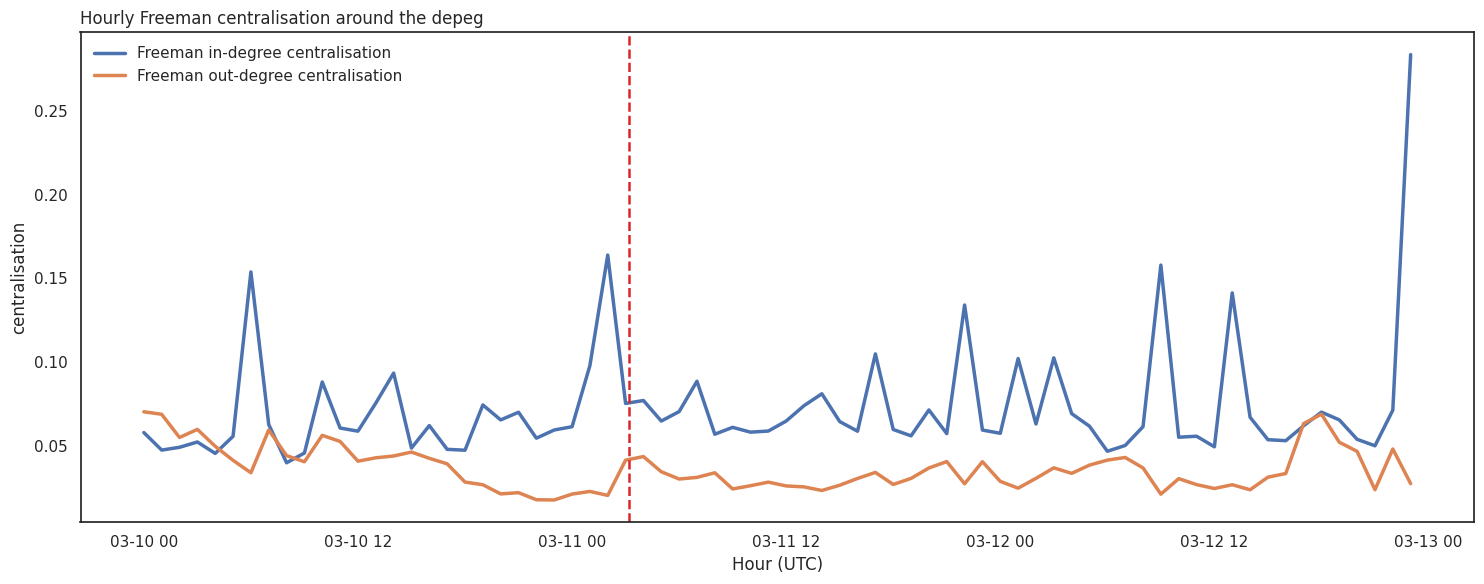

In [151]:
def freeman_degree_centralisation(degree_values):
    values = np.asarray(list(degree_values), dtype=float)
    n_nodes = values.size
    if n_nodes <= 1:
        return np.nan
    numerator = np.sum(values.max() - values)
    denominator = (n_nodes - 1) ** 2
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compute_hourly_freeman_centralisation(df_edges):
    rows = []
    for ts_hour, sub in df_edges.groupby("ts_hour", sort=True):
        graph = build_graph(sub)
        if graph.number_of_nodes() <= 1:
            continue

        in_degree = dict(graph.in_degree()).values()
        out_degree = dict(graph.out_degree()).values()

        rows.append({
            "ts_hour": ts_hour,
            "freeman_in_degree": freeman_degree_centralisation(in_degree),
            "freeman_out_degree": freeman_degree_centralisation(out_degree),
        })

    return pd.DataFrame(rows)


freeman_df = compute_hourly_freeman_centralisation(df_net)

pre_mask = freeman_df["ts_hour"].between(PRE_START, PRE_END)
event_mask = freeman_df["ts_hour"].between(EVENT_START, EVENT_END)

centralisation_window = pd.DataFrame([{
    "pre_in": freeman_df.loc[pre_mask, "freeman_in_degree"].mean(),
    "event_in": freeman_df.loc[event_mask, "freeman_in_degree"].mean(),
    "pre_out": freeman_df.loc[pre_mask, "freeman_out_degree"].mean(),
    "event_out": freeman_df.loc[event_mask, "freeman_out_degree"].mean(),
}])
centralisation_window["delta_in"] = centralisation_window["event_in"] - centralisation_window["pre_in"]
centralisation_window["delta_out"] = centralisation_window["event_out"] - centralisation_window["pre_out"]
display(centralisation_window)

plt.figure(figsize=(15, 6))
plt.plot(freeman_df["ts_hour"], freeman_df["freeman_in_degree"], linewidth=2.5, label="Freeman in-degree centralisation")
plt.plot(freeman_df["ts_hour"], freeman_df["freeman_out_degree"], linewidth=2.5, label="Freeman out-degree centralisation")
plt.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
plt.title("Hourly Freeman centralisation around the depeg", loc="left")
plt.xlabel("Hour (UTC)")
plt.ylabel("centralisation")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Additional Centralities Through Time

This section computes hourly weighted betweenness, Katz centrality, and eigenvector centrality on the directed weighted transfer graph.

For weighted betweenness, edge cost is set to $1/(\mathrm{amount\_usdc}+\epsilon)$ so larger transfer edges are treated as shorter paths.

For scalability, betweenness is approximated with node sampling when graphs are large.

,node,short_label,family,category,is_labelled,pre_weighted_betweenness,event_weighted_betweenness,delta_abs_weighted_betweenness,delta_log_weighted_betweenness,pre_katz,event_katz,delta_abs_katz,delta_log_katz,pre_eigenvector,event_eigenvector,delta_abs_eigenvector,delta_log_eigenvector
135248,UniswapV3_USDC_USDT_500,UniswapV3_USDC_USDT_500,dex_pool,dex_pool,True,0.0044,0.0369,0.0325,0.0319,0.0175,0.0222,0.0047,0.0046,0.0032,0.1090,0.1059,0.1003
135226,Curve_3Pool,Curve_3Pool,dex_pool,dex_pool,True,0.0204,0.0461,0.0257,0.0248,0.0201,0.0296,0.0094,0.0092,0.0123,0.2851,0.2728,0.2386
135233,Kraken,Kraken,CEX,CEX,True,0.0131,0.0299,0.0167,0.0164,0.0181,0.0161,-0.0019,-0.0019,0.0000,0.0000,0.0000,0.0000
135234,MEV_bot,MEV_bot,mev_bot,mev_bot,True,0.0071,0.0190,0.0119,0.0118,0.0181,0.0228,0.0046,0.0045,0.0132,0.1892,0.1760,0.1602
135236,MEV_bot_2,MEV_bot_2,mev_bot,mev_bot,True,0.0042,0.0138,0.0096,0.0095,0.0190,0.0157,-0.0033,-0.0032,0.0092,0.0209,0.0117,0.0116
135210,Aave_aUSDC_Token_V2,Aave aUSDC,Lending,lending_token,True,0.0150,0.0213,0.0063,0.0062,0.0183,0.0264,0.0081,0.0080,0.0029,0.2254,0.2225,0.2004
135227,Curve_router,Curve_router,aggregator_router,aggregator_router,True,0.0067,0.0120,0.0053,0.0052,0.0185,0.0157,-0.0028,-0.0027,0.0017,0.0321,0.0304,0.0299
135246,UniswapV3_USDC_DAI_500,UniswapV3_USDC_DAI_500,dex_pool,dex_pool,True,0.0001,0.0037,0.0037,0.0037,0.0191,0.0193,0.0002,0.0002,0.0588,0.0112,-0.0476,-0.0460
135231,FillQuoteTransformer,FillQuoteTransformer,contract,contract,True,0.0033,0.0068,0.0034,0.0034,0.0176,0.0160,-0.0015,-0.0015,0.0017,0.0442,0.0425,0.0415
135243,OneInch_Aggregation_Router_V5,1inch Router,Routing,aggregator_router,True,0.0125,0.0148,0.0024,0.0023,0.0183,0.0182,-0.0001,-0.0001,0.0101,0.0885,0.0783,0.0747


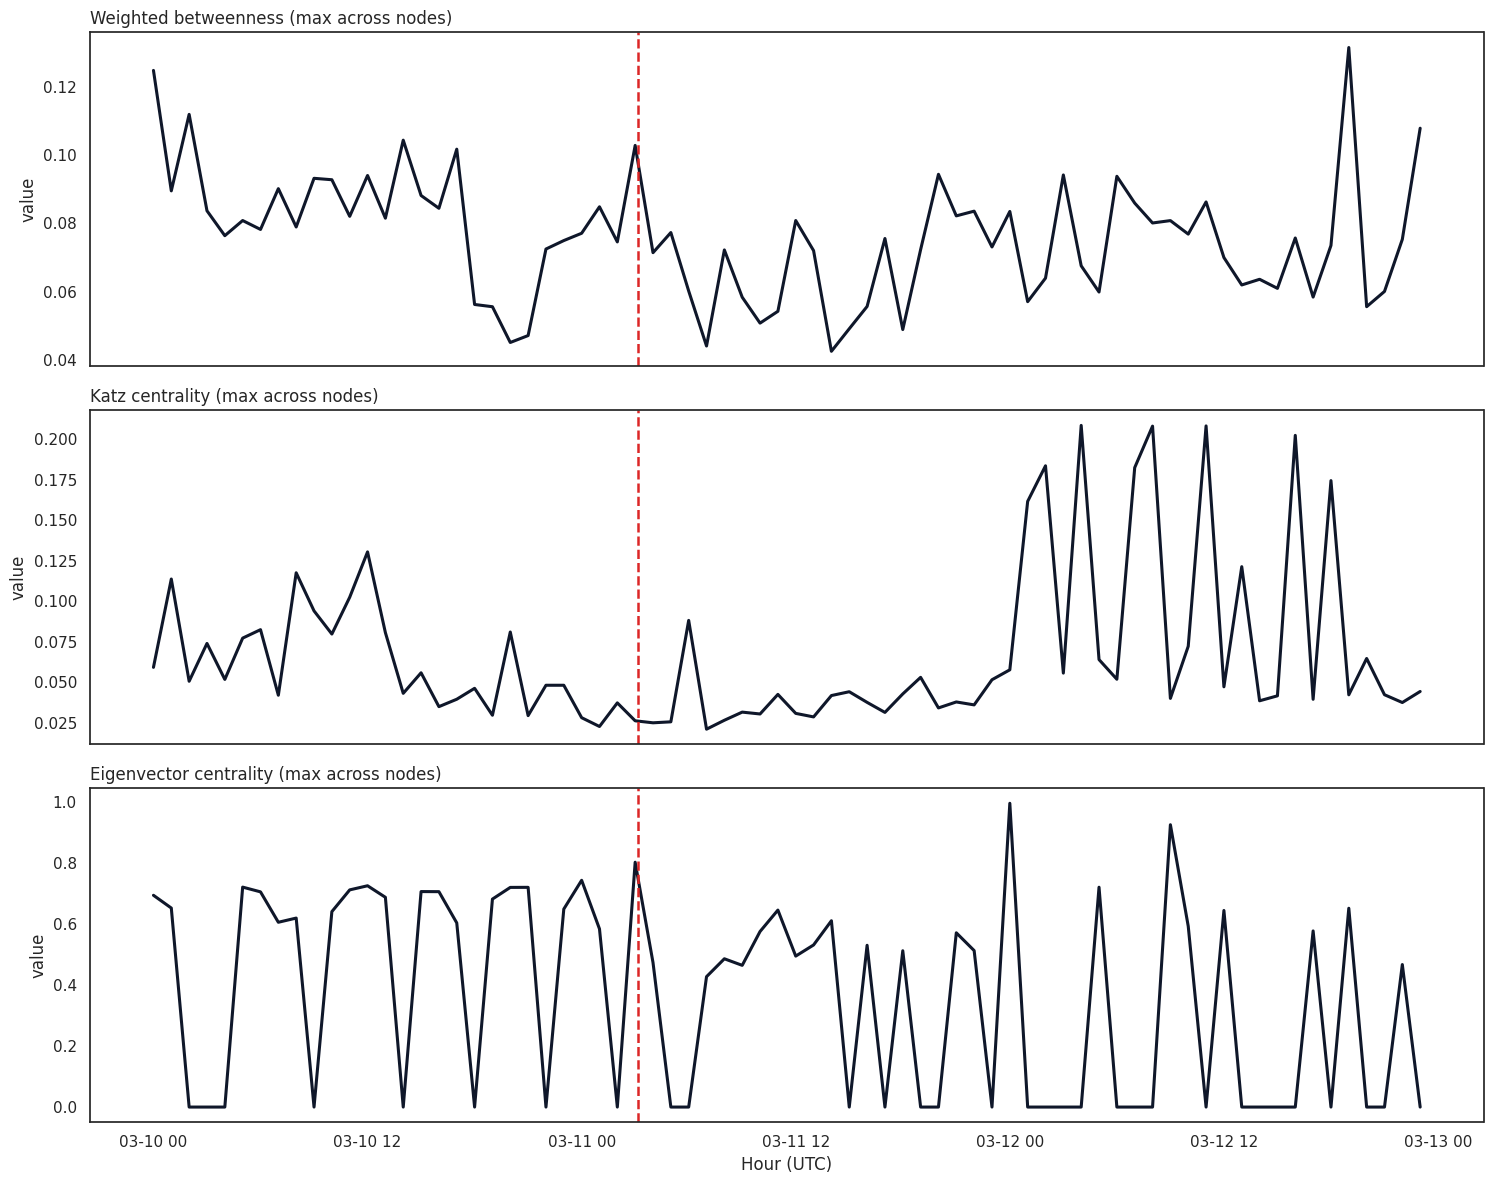

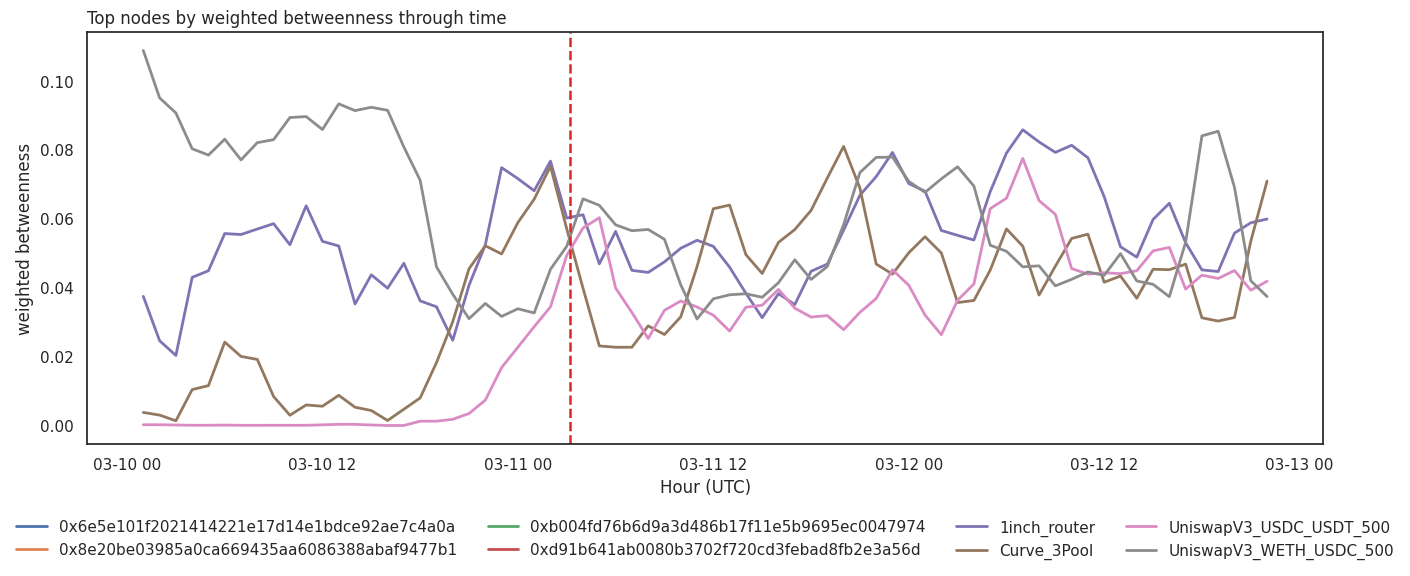

In [160]:
def compute_hourly_additional_centralities(df_edges, betweenness_sample=120, eps=1e-9):
    node_rows = []
    graph_rows = []

    for ts_hour, sub in df_edges.groupby("ts_hour", sort=True):
        graph = build_graph(sub)
        n_nodes = graph.number_of_nodes()
        if n_nodes <= 1:
            continue

        # Convert transfer volume to path cost for betweenness shortest paths.
        for u, v, data in graph.edges(data=True):
            data["cost"] = 1.0 / (float(data.get("weight", 0.0)) + eps)

        if n_nodes > betweenness_sample:
            w_betweenness = nx.betweenness_centrality(
                graph,
                k=betweenness_sample,
                weight="cost",
                normalized=True,
                seed=42,
            )
        else:
            w_betweenness = nx.betweenness_centrality(
                graph,
                weight="cost",
                normalized=True,
            )

        max_out_strength = max(dict(graph.out_degree(weight="weight")).values()) if graph.number_of_edges() > 0 else 1.0
        alpha = 0.9 / max(max_out_strength, 1.0)

        try:
            katz = nx.katz_centrality(
                graph,
                alpha=alpha,
                beta=1.0,
                weight="weight",
                normalized=True,
                max_iter=2000,
                tol=1e-6,
            )
        except Exception:
            try:
                katz = nx.katz_centrality(
                    graph,
                    alpha=alpha * 0.2,
                    beta=1.0,
                    weight="weight",
                    normalized=True,
                    max_iter=3000,
                    tol=1e-6,
                )
            except Exception:
                katz = {n: 0.0 for n in graph.nodes()}

        try:
            eig = nx.eigenvector_centrality(
                graph,
                max_iter=2000,
                tol=1e-6,
                weight="weight",
            )
        except Exception:
            try:
                largest_component = max(nx.weakly_connected_components(graph), key=len)
                sub_graph = graph.subgraph(largest_component).copy()
                eig_sub = nx.eigenvector_centrality(
                    sub_graph,
                    max_iter=3000,
                    tol=1e-6,
                    weight="weight",
                )
                eig = {n: 0.0 for n in graph.nodes()}
                eig.update(eig_sub)
            except Exception:
                eig = {n: 0.0 for n in graph.nodes()}

        graph_rows.append({
            "ts_hour": ts_hour,
            "max_weighted_betweenness": np.max(list(w_betweenness.values())) if len(w_betweenness) else np.nan,
            "max_katz": np.max(list(katz.values())) if len(katz) else np.nan,
            "max_eigenvector": np.max(list(eig.values())) if len(eig) else np.nan,
            "mean_weighted_betweenness": np.mean(list(w_betweenness.values())) if len(w_betweenness) else np.nan,
            "mean_katz": np.mean(list(katz.values())) if len(katz) else np.nan,
            "mean_eigenvector": np.mean(list(eig.values())) if len(eig) else np.nan,
            "n_nodes": n_nodes,
        })

        for node in graph.nodes():
            category = category_map.get(node, "unknown")
            node_rows.append({
                "ts_hour": ts_hour,
                "node": node,
                "short_label": short_label_map.get(node, node),
                "family": family_map.get(node, category),
                "category": category,
                "weighted_betweenness": w_betweenness.get(node, 0.0),
                "katz": katz.get(node, 0.0),
                "eigenvector": eig.get(node, 0.0),
            })

    return pd.DataFrame(node_rows), pd.DataFrame(graph_rows)


def summarize_pre_event_for_metric(node_df, metric, pre_start, pre_end, event_start, event_end):
    pre = (
        node_df[node_df["ts_hour"].between(pre_start, pre_end)]
        .groupby(["node", "short_label", "category", "family"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: f"pre_{metric}"})
    )
    event = (
        node_df[node_df["ts_hour"].between(event_start, event_end)]
        .groupby(["node", "short_label", "category", "family"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: f"event_{metric}"})
    )
    out = pre.merge(event, on=["node", "short_label", "category", "family"], how="outer").fillna(0)
    out[f"delta_abs_{metric}"] = out[f"event_{metric}"] - out[f"pre_{metric}"]
    out[f"delta_log_{metric}"] = np.log1p(out[f"event_{metric}"]) - np.log1p(out[f"pre_{metric}"])
    out["is_labelled"] = ~out["node"].str.fullmatch(r"0x[a-f0-9]{40}")
    return out


extra_node_metrics, extra_graph_metrics = compute_hourly_additional_centralities(df_net)

btw_changes = summarize_pre_event_for_metric(extra_node_metrics, "weighted_betweenness", PRE_START, PRE_END, EVENT_START, EVENT_END)
katz_changes = summarize_pre_event_for_metric(extra_node_metrics, "katz", PRE_START, PRE_END, EVENT_START, EVENT_END)
eig_changes = summarize_pre_event_for_metric(extra_node_metrics, "eigenvector", PRE_START, PRE_END, EVENT_START, EVENT_END)

centrality_delta = (
    btw_changes[[
        "node", "short_label", "family", "category", "is_labelled",
        "pre_weighted_betweenness", "event_weighted_betweenness",
        "delta_abs_weighted_betweenness", "delta_log_weighted_betweenness",
    ]]
    .merge(
        katz_changes[[
            "node", "pre_katz", "event_katz", "delta_abs_katz", "delta_log_katz",
        ]],
        on="node",
        how="left",
    )
    .merge(
        eig_changes[[
            "node", "pre_eigenvector", "event_eigenvector", "delta_abs_eigenvector", "delta_log_eigenvector",
        ]],
        on="node",
        how="left",
    )
)
display(centrality_delta[centrality_delta["is_labelled"]].sort_values("delta_abs_weighted_betweenness", ascending=False).head(15))

plot_metrics = [
    ("max_weighted_betweenness", "Weighted betweenness (max across nodes)"),
    ("max_katz", "Katz centrality (max across nodes)"),
    ("max_eigenvector", "Eigenvector centrality (max across nodes)"),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for ax, (metric, title) in zip(axes, plot_metrics):
    ax.plot(extra_graph_metrics["ts_hour"], extra_graph_metrics[metric], linewidth=2.2, color="#0f172a")
    ax.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
    ax.set_title(title, loc="left")
    ax.set_ylabel("value")

axes[-1].set_xlabel("Hour (UTC)")
plt.tight_layout()
plt.show()

focus_metric = "weighted_betweenness"
top_nodes_metric = (
    extra_node_metrics[extra_node_metrics["ts_hour"].between(EVENT_START, EVENT_END)]
    .groupby(["node", "short_label"], as_index=False)[focus_metric]
    .mean()
    .sort_values(focus_metric, ascending=False)
    .head(8)["node"]
    .tolist()
)

top_metric_df = extra_node_metrics[extra_node_metrics["node"].isin(top_nodes_metric)].copy()

plt.figure(figsize=(15, 6))
for node, sub in top_metric_df.groupby("node"):
    plt.plot(
        sub["ts_hour"],
        sub[focus_metric].rolling(3, center=True).mean(),
        linewidth=2,
        label=sub["short_label"].iloc[0],
    )
plt.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
plt.title("Top nodes by weighted betweenness through time", loc="left")
plt.xlabel("Hour (UTC)")
plt.ylabel("weighted betweenness")
plt.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

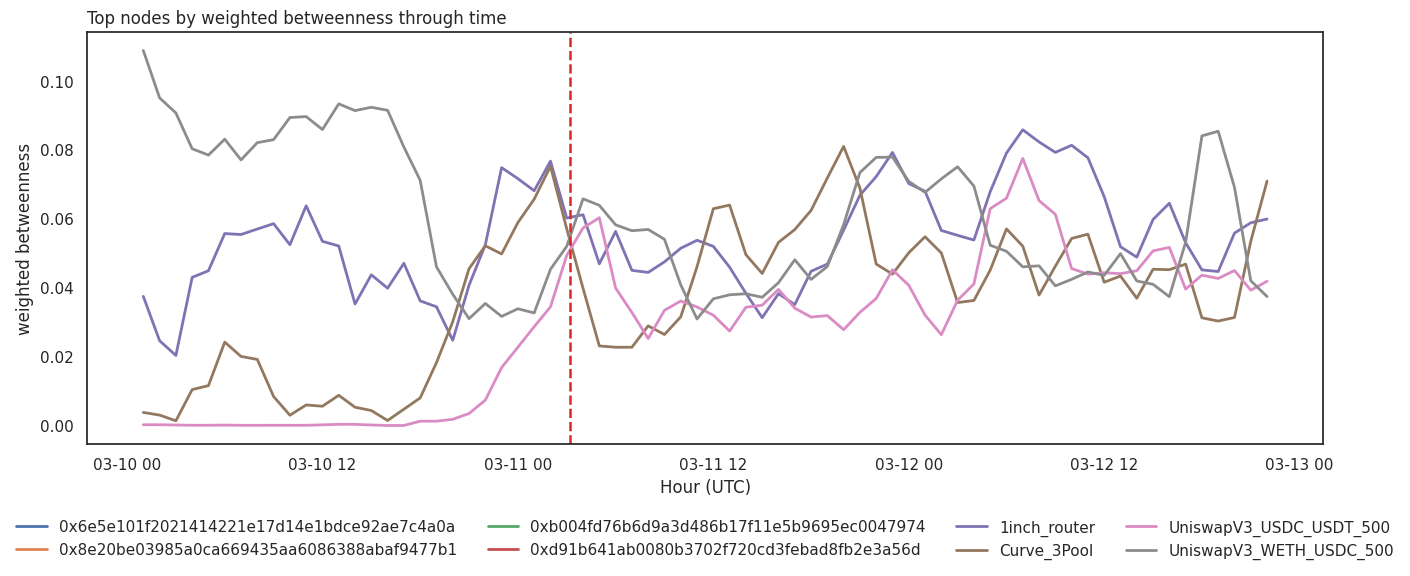

In [162]:
focus_metric = "weighted_betweenness"
top_nodes_metric = (
    extra_node_metrics[extra_node_metrics["ts_hour"].between(EVENT_START, EVENT_END)]
    .groupby(["node", "short_label"], as_index=False)[focus_metric]
    .mean()
    .sort_values(focus_metric, ascending=False)
    .head(8)["node"]
    .tolist()
)

top_metric_df = extra_node_metrics[extra_node_metrics["node"].isin(top_nodes_metric)].copy()

plt.figure(figsize=(15, 6))
for node, sub in top_metric_df.groupby("node"):
    plt.plot(
        sub["ts_hour"],
        sub[focus_metric].rolling(3, center=True).mean(),
        linewidth=2,
        label=sub["short_label"].iloc[0],
    )
plt.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
plt.title("Top nodes by weighted betweenness through time", loc="left")
plt.xlabel("Hour (UTC)")
plt.ylabel("weighted betweenness")
plt.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

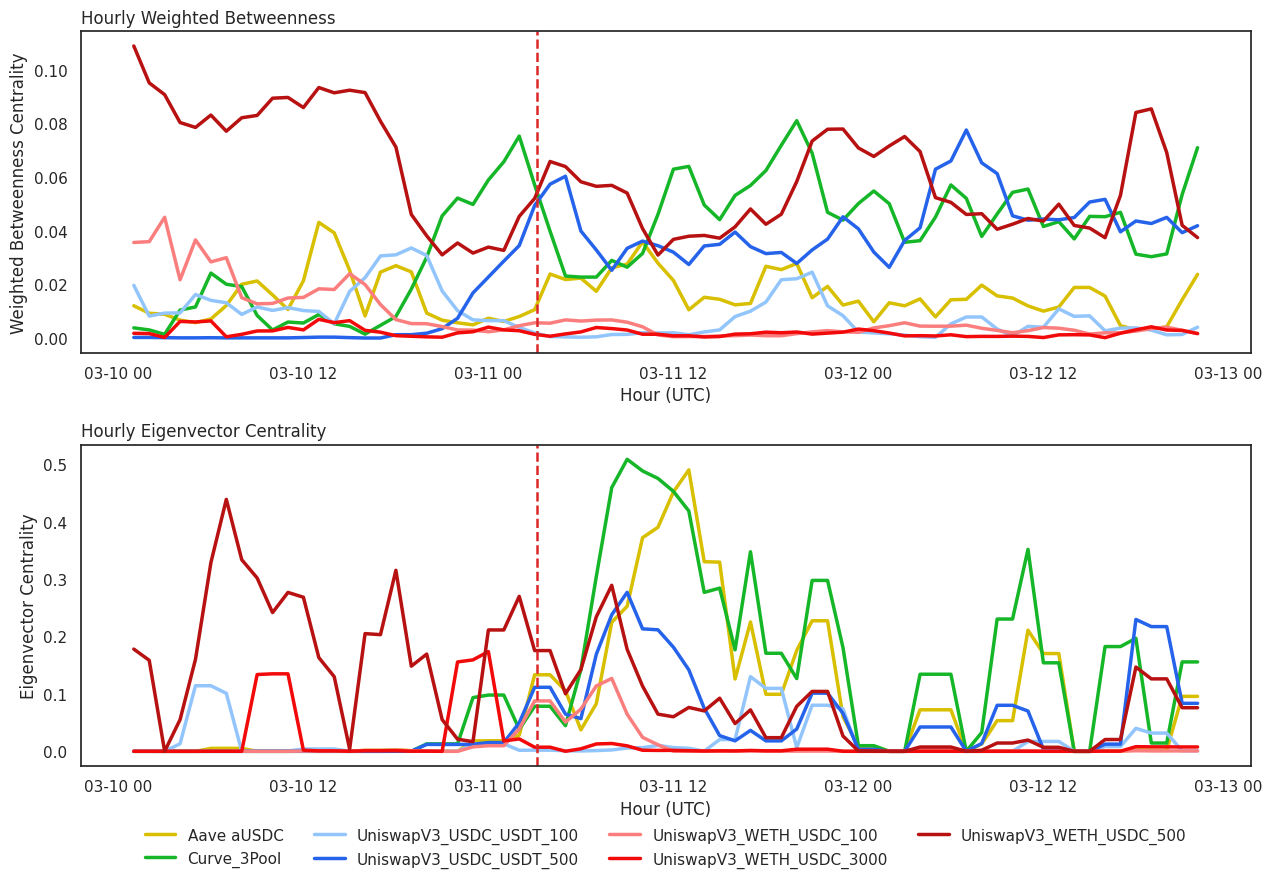

In [168]:
focus_nodes = [
    "Curve_3Pool",
    "UniswapV3_USDC_USDT_100",
    "UniswapV3_USDC_USDT_500",
    "UniswapV3_WETH_USDC_100",
    "UniswapV3_WETH_USDC_500",
    "UniswapV3_WETH_USDC_3000",
    "Aave_aUSDC_Token_V2",
]

# Semantic palette: distinct colors for Curve/Aave + gradients per Uniswap family
node_colors = {
    "Curve_3Pool": "#15b628",                     # Curve green
    "Aave_aUSDC_Token_V2": "#d8bf00",             # Aave gold
    "UniswapV3_USDC_USDT_100": "#93c5fd",         # light blue
    "UniswapV3_USDC_USDT_500": "#2563eb",         # deep blue
    "UniswapV3_WETH_USDC_100": "#fb7e7e",         # light orange
    "UniswapV3_WETH_USDC_500": "#b81111",         # orange
    "UniswapV3_WETH_USDC_3000": "#f20909",        # deep red
}

plot_df = extra_node_metrics[extra_node_metrics["node"].isin(focus_nodes)].copy()
plot_df["label"] = plot_df["short_label"]

if plot_df.empty:
    print("No selected focus nodes were found in extra_node_metrics. Check focus_nodes names.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(13, 9))

    for node, sub in plot_df.groupby("node"):
        display_label = sub["label"].iloc[0]
        color = node_colors.get(node, "#6b7280")
        axes[0].plot(
            sub["ts_hour"],
            sub["weighted_betweenness"].rolling(3, center=True).mean(),
            linewidth=2.5,
            label=display_label,
            color=color,
        )
        axes[1].plot(
            sub["ts_hour"],
            sub["eigenvector"].rolling(3, center=True).mean(),
            linewidth=2.5,
            label=display_label,
            color=color,
        )
       

    for ax, title, ylabel in [
        (axes[0], "Hourly Weighted Betweenness", "Weighted Betweenness Centrality"),
        (axes[1], "Hourly Eigenvector Centrality", "Eigenvector Centrality"),
    ]:
        ax.axvline(DEPEG_TS, color="#dc2626", linestyle="--", linewidth=1.8)
        ax.set_title(title, loc="left")
        ax.set_ylabel(ylabel)

    axes[0].set_xlabel("Hour (UTC)")
    axes[1].set_xlabel("Hour (UTC)")
    # axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False, ncols=4)
    axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False, ncols=4)
    plt.tight_layout()
    plt.savefig("USDC_betwenness_time_series.png", dpi=300, transparent=True, bbox_inches="tight")
    plt.show()